# 💳 Credit Card Fraud Detection
### Industry: Finance

---

**Description:**  
This project develops a system to detect fraudulent credit card transactions in real-time using transaction data. We follow a complete ML pipeline:

1. Load & Explore the dataset
2. Handle class imbalance using SMOTE / undersampling
3. Train models: Logistic Regression, XGBoost, and Autoencoder
4. Evaluate using ROC-AUC and Confusion Matrix
5. Simulate real-time detection on test data

**Tools:** Python, Scikit-learn, Imbalanced-learn, TensorFlow

## 📦 Step 0: Install & Import Libraries

We install and import all required libraries. Key ones include:
- `imbalanced-learn` for SMOTE (handling class imbalance)
- `xgboost` for the gradient-boosted tree model
- `tensorflow` for the deep-learning Autoencoder
- `scikit-learn` for preprocessing, metrics, and Logistic Regression

In [1]:
# Install required libraries (run once in Colab)
!pip install imbalanced-learn xgboost --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('✅ All libraries loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')

✅ All libraries loaded successfully!
TensorFlow version: 2.20.0


---
## 📂 Step 1: Load & Explore the Dataset

The dataset contains **284,807 credit card transactions** made by European cardholders in September 2013.

**Features:**
- `Time` – Seconds elapsed between each transaction and the first transaction
- `V1–V28` – Anonymized PCA components (to protect user privacy)
- `Amount` – Transaction amount in euros
- `Class` – Target label: **1 = Fraud**, **0 = Legitimate**

> 📌 Upload `creditcard.csv` to your Colab session or mount Google Drive before running.

In [3]:
# ─── Option A: Upload directly in Colab ───────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()  # Select creditcard.csv
# df = pd.read_csv('creditcard.csv')

# ─── Option B: Mount Google Drive ─────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

# ─── Option C: Read from local path (if running locally) ──────────────────────
df = pd.read_csv('creditcard.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nMissing values:\n{df.isnull().sum().sum()} total missing values')
print(f'\nData types:\n{df.dtypes.value_counts()}')

=== Dataset Info ===
Rows    : 284,807
Columns : 31

Missing values:
0 total missing values

Data types:
float64    30
int64       1
Name: count, dtype: int64


In [5]:
# ── Statistical summary ────────────────────────────────────────────────────────
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


=== Class Distribution ===
Legitimate (0): 284,315  (99.8273%)
Fraud      (1): 492  (0.1727%)


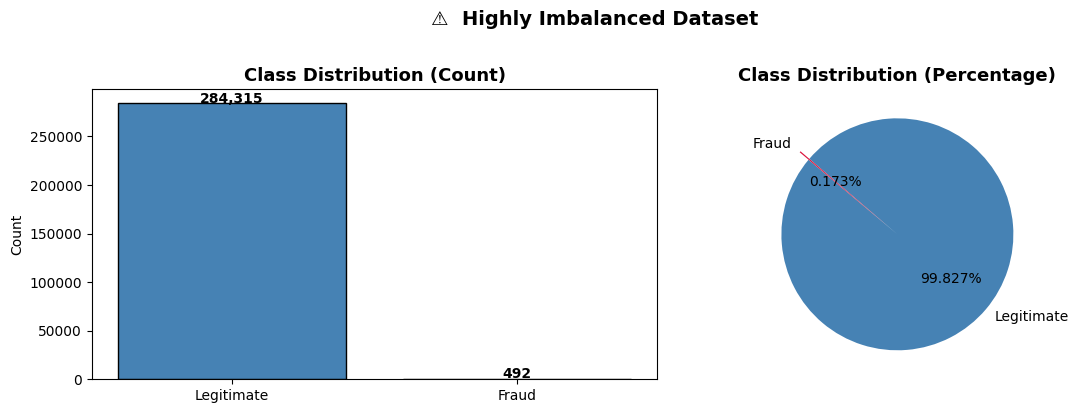


⚠️  Only 0.17% of transactions are fraudulent — this is a highly imbalanced dataset!


In [6]:
# ── Class distribution ─────────────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
fraud_pct = (class_counts[1] / len(df)) * 100

print('=== Class Distribution ===')
print(f'Legitimate (0): {class_counts[0]:,}  ({100 - fraud_pct:.4f}%)')
print(f'Fraud      (1): {class_counts[1]:,}  ({fraud_pct:.4f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'],
            startangle=140, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.suptitle('⚠️  Highly Imbalanced Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n⚠️  Only 0.17% of transactions are fraudulent — this is a highly imbalanced dataset!')

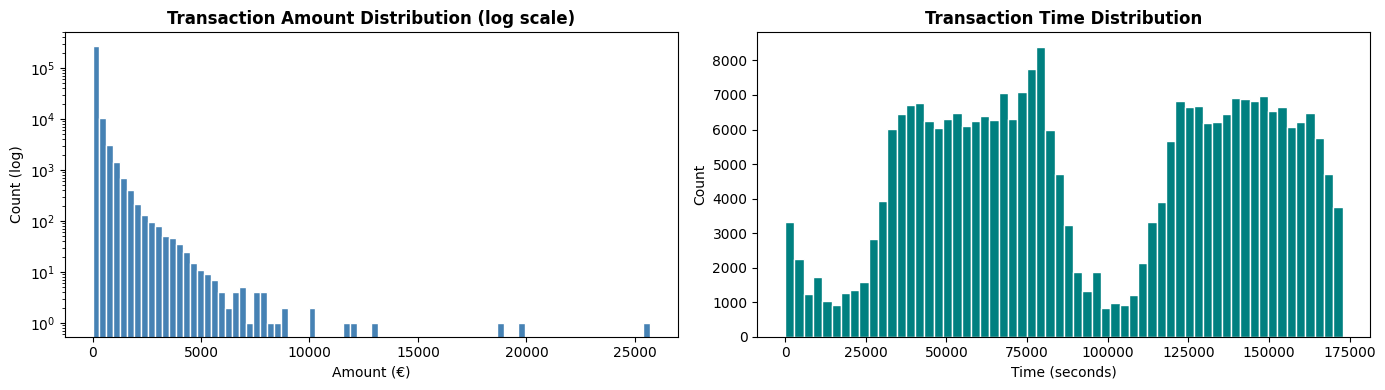

In [7]:
# ── Distribution of Amount and Time ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=80, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Transaction Amount Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count (log)')

axes[1].hist(df['Time'], bins=60, color='teal', edgecolor='white')
axes[1].set_title('Transaction Time Distribution', fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

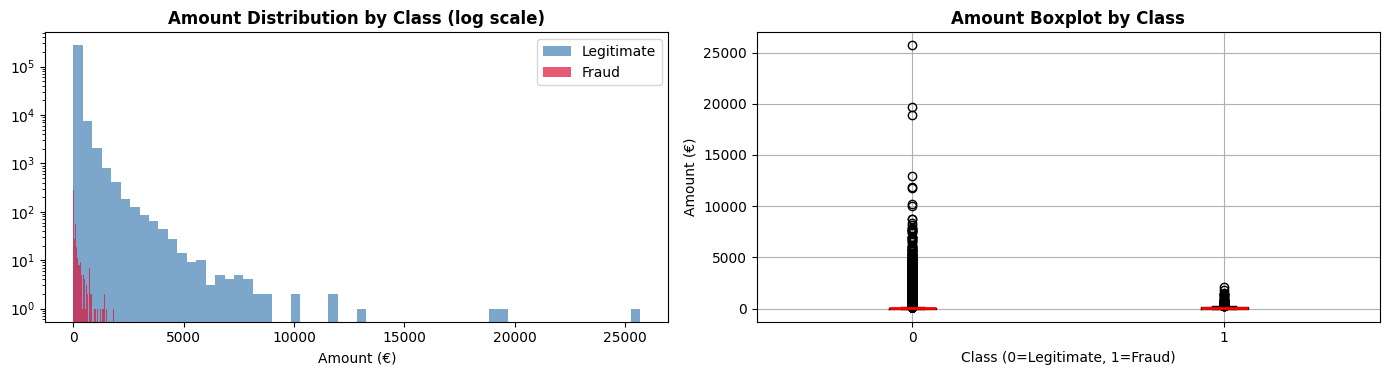

In [8]:
# ── Amount comparison: Fraud vs Legitimate ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cls, label, color in [(0, 'Legitimate', 'steelblue'), (1, 'Fraud', 'crimson')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[0].hist(subset, bins=60, alpha=0.7, label=label, color=color, log=True)
axes[0].set_title('Amount Distribution by Class (log scale)', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].legend()

df.boxplot(column='Amount', by='Class', ax=axes[1],
           boxprops=dict(color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Boxplot by Class', fontweight='bold')
axes[1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[1].set_ylabel('Amount (€)')
plt.suptitle('')

plt.tight_layout()
plt.show()

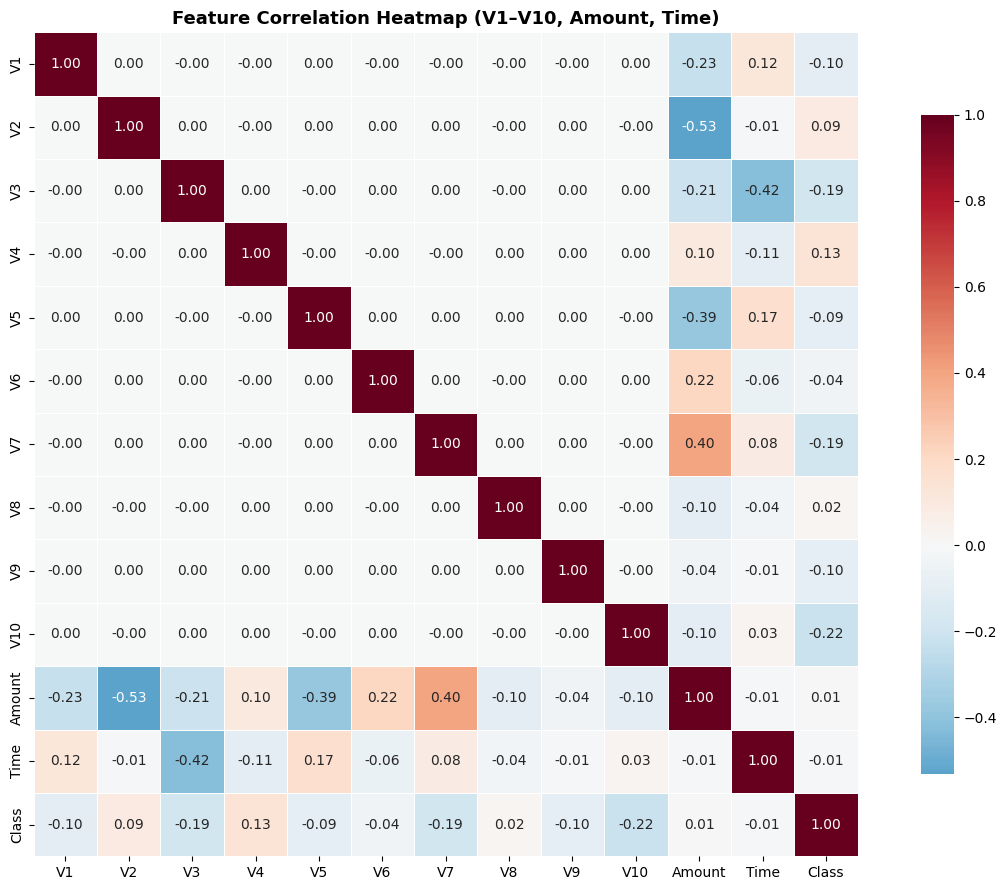

In [9]:
# ── Correlation heatmap (selected features) ────────────────────────────────────
# Show correlation of V1-V10, Amount, Time with Class
selected_cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                 'Amount','Time','Class']
corr = df[selected_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (V1–V10, Amount, Time)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## ⚖️ Step 2: Preprocessing & Handling Class Imbalance

### Why is imbalance a problem?
With only **0.17%** fraud cases, a naive model that predicts *everything as legitimate* would achieve 99.83% accuracy — but catch **zero frauds!** This is useless in practice.

### Solutions:
1. **SMOTE (Synthetic Minority Over-sampling Technique)** – Generates synthetic fraud samples by interpolating between existing fraud samples
2. **Random Undersampling** – Reduces majority class (legitimate) samples
3. **Combined approach** – SMOTE + Undersampling (best of both worlds)

We also **scale** `Amount` and `Time` since PCA features V1–V28 are already normalized.

In [10]:
# ── Feature scaling ────────────────────────────────────────────────────────────
# Amount and Time are the only non-PCA features; scale them to match V1-V28
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled['Amount'] = scaler.fit_transform(df[['Amount']])
df_scaled['Time']   = scaler.fit_transform(df[['Time']])

X = df_scaled.drop('Class', axis=1).values
y = df_scaled['Class'].values

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Fraud samples        : {y.sum():,}')
print(f'Legit samples        : {(y==0).sum():,}')

Feature matrix shape : (284807, 30)
Target vector shape  : (284807,)
Fraud samples        : 492
Legit samples        : 284,315


In [11]:
# ── Train/Test split (stratified to preserve fraud ratio) ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} samples  | Fraud: {y_train.sum():,}')
print(f'Test set      : {X_test.shape[0]:,} samples   | Fraud: {y_test.sum():,}')

Training set  : 227,845 samples  | Fraud: 394
Test set      : 56,962 samples   | Fraud: 98


=== After Resampling (Training Set) ===
  Legitimate (0): 45,490
  Fraud (1): 22,745


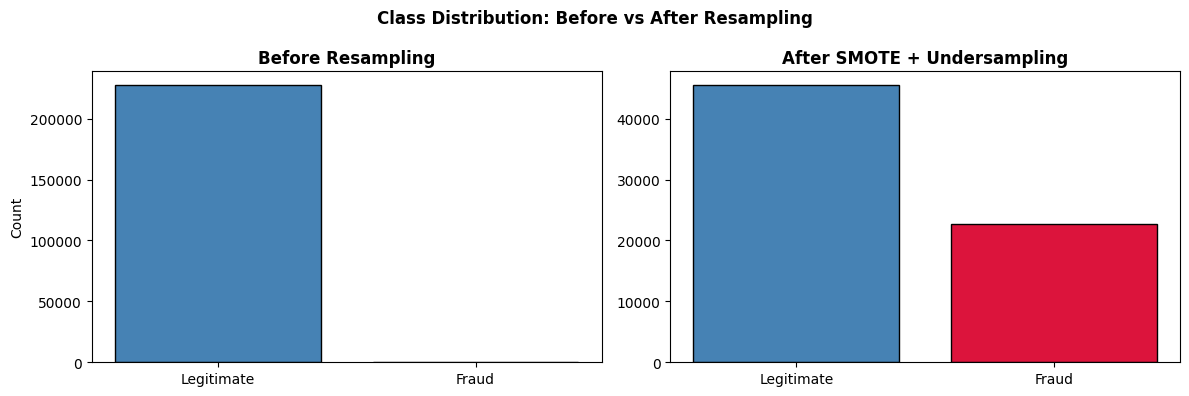

In [12]:
# ── SMOTE + Undersampling on training data ─────────────────────────────────────
# Strategy: oversample minority (fraud) to 10% of majority, then undersample majority
over  = SMOTE(sampling_strategy=0.1, random_state=42)   # fraud → 10% of legit
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # legit → 2x fraud

pipeline_resample = ImbPipeline(steps=[('o', over), ('u', under)])
X_res, y_res = pipeline_resample.fit_resample(X_train, y_train)

unique, counts = np.unique(y_res, return_counts=True)
print('=== After Resampling (Training Set) ===')
for u, c in zip(unique, counts):
    label = 'Fraud' if u == 1 else 'Legitimate'
    print(f'  {label} ({u}): {c:,}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], [np.sum(y_train==0), np.sum(y_train==1)],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Before Resampling', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'], [np.sum(y_res==0), np.sum(y_res==1)],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title('After SMOTE + Undersampling', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Resampling', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🤖 Step 3: Model Training

We train **three different models** to compare performance:

| Model | Type | Key Strength |
|---|---|---|
| **Logistic Regression** | Linear classifier | Fast, interpretable baseline |
| **XGBoost** | Gradient boosted trees | Handles non-linearity, very powerful |
| **Autoencoder** | Neural network | Learns normal patterns; flags anomalies |

### 3a. Logistic Regression
A classic linear model used as a **baseline**. We use `class_weight='balanced'` as an additional safeguard against imbalance. It outputs probabilities for each class.

In [13]:
# ── Logistic Regression ────────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_res, y_res)

lr_pred      = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]

print('✅ Logistic Regression trained!')
print(f'   ROC-AUC Score: {roc_auc_score(y_test, lr_pred_prob):.4f}')

Training Logistic Regression...
✅ Logistic Regression trained!
   ROC-AUC Score: 0.9695


### 3b. XGBoost Classifier
XGBoost is a powerful gradient-boosting algorithm. The `scale_pos_weight` parameter compensates for class imbalance by giving more weight to the minority (fraud) class during training.

In [14]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
# scale_pos_weight = ratio of negative/positive in original training set
neg_pos_ratio = int(np.sum(y_train == 0) / np.sum(y_train == 1))
print(f'neg/pos ratio for XGBoost scale_pos_weight: {neg_pos_ratio}')

print('\nTraining XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_res, y_res)

xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print('✅ XGBoost trained!')
print(f'   ROC-AUC Score: {roc_auc_score(y_test, xgb_pred_prob):.4f}')

neg/pos ratio for XGBoost scale_pos_weight: 577

Training XGBoost...
✅ XGBoost trained!
   ROC-AUC Score: 0.9783


### 3c. Autoencoder (Anomaly Detection)
An **Autoencoder** is a neural network trained to reconstruct its input. We train it **only on legitimate transactions**, so it learns the pattern of normal behavior.

At inference, fraudulent transactions will have a **high reconstruction error** (they look "unusual") — we use this error as a fraud score.

In [15]:
# ── Autoencoder ────────────────────────────────────────────────────────────────
# Train ONLY on legitimate transactions (anomaly detection approach)
X_train_legit = X_res[y_res == 0]
print(f'Training Autoencoder on {len(X_train_legit):,} legitimate transactions...')

input_dim = X_train_legit.shape[1]

# Build the Autoencoder
def build_autoencoder(input_dim):
    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    encoded = layers.Dense(16, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.Dense(32, activation='relu')(encoded)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='linear')(x)

    model = keras.Model(inputs, outputs, name='Autoencoder')
    return model

autoencoder = build_autoencoder(input_dim)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Training Autoencoder on 45,490 legitimate transactions...


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,198 (35.93 KB)

 Trainable params: 9,198 (35.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8790 - val_loss: 0.6025
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5733 - val_loss: 0.4207
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4779 - val_loss: 0.3629
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4400 - val_loss: 0.3238
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4111 - val_loss: 0.2961
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3917 - val_loss: 0.2799
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3774 - val_loss: 0.2665
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3637 - val_loss: 0.2459
Epoch 9/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3576 - val_loss: 0.2420
Epoch 10/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3492 - val_loss: 0.2299
Epoch 11/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3403 - val_loss: 0.2206
Epoch 12/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

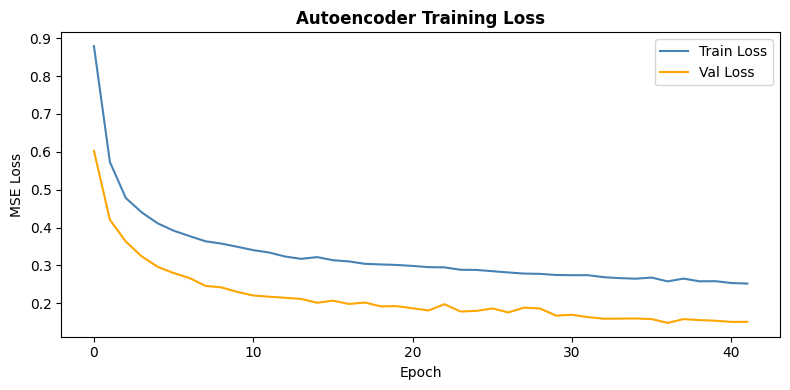

In [16]:
# ── Train Autoencoder ──────────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_legit, X_train_legit,  # input == output (reconstruction)
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Autoencoder Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

Reconstruction error threshold (95th pct of legit): 0.420468
Mean error — Legitimate : 0.150751
Mean error — Fraud      : 17.335494


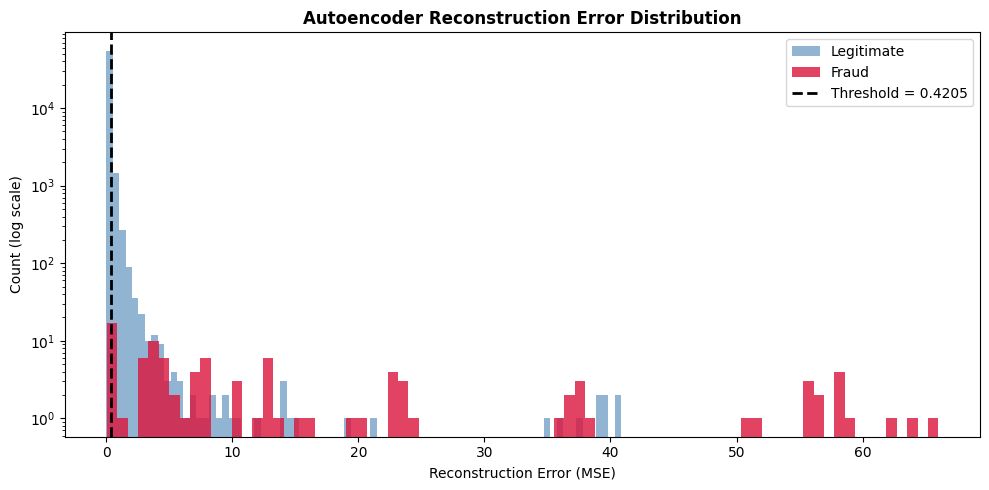


✅ Autoencoder threshold set. ROC-AUC: 0.9620


In [17]:
# ── Autoencoder: compute reconstruction error on test set ──────────────────────
X_test_reconstructed = autoencoder.predict(X_test, verbose=0)
reconstruction_error = np.mean(np.power(X_test - X_test_reconstructed, 2), axis=1)

# Find optimal threshold using 95th percentile of legitimate transaction errors
legit_errors  = reconstruction_error[y_test == 0]
fraud_errors  = reconstruction_error[y_test == 1]
threshold     = np.percentile(legit_errors, 95)

print(f'Reconstruction error threshold (95th pct of legit): {threshold:.6f}')
print(f'Mean error — Legitimate : {legit_errors.mean():.6f}')
print(f'Mean error — Fraud      : {fraud_errors.mean():.6f}')

# Visualize reconstruction error distribution
plt.figure(figsize=(10, 5))
plt.hist(legit_errors, bins=80, alpha=0.6, label='Legitimate', color='steelblue', log=True)
plt.hist(fraud_errors, bins=80, alpha=0.8, label='Fraud', color='crimson', log=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.title('Autoencoder Reconstruction Error Distribution', fontweight='bold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

# Predict
ae_pred      = (reconstruction_error > threshold).astype(int)
ae_pred_prob = reconstruction_error  # use raw error as fraud score

print(f'\n✅ Autoencoder threshold set. ROC-AUC: {roc_auc_score(y_test, ae_pred_prob):.4f}')

---
## 📊 Step 4: Evaluation — ROC-AUC & Confusion Matrix

### Why ROC-AUC and not plain accuracy?
With imbalanced data, **accuracy is misleading**. ROC-AUC measures the model's ability to distinguish between classes across all thresholds — it's the gold standard for fraud detection.

- **ROC-AUC = 1.0** → Perfect classifier
- **ROC-AUC = 0.5** → Random guessing

The **Confusion Matrix** breaks predictions into:
- **TP** (True Positives): Correctly detected fraud
- **TN** (True Negatives): Correctly identified legitimate
- **FP** (False Positives): Legitimate flagged as fraud (false alarm)
- **FN** (False Negatives): Missed fraud (most dangerous!)

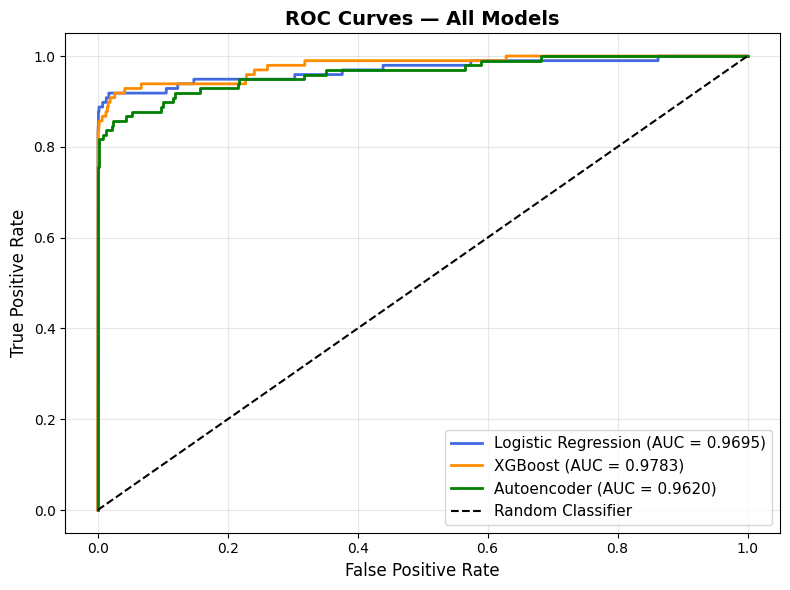

In [18]:
# ── ROC Curves for all models ──────────────────────────────────────────────────
models_info = [
    ('Logistic Regression', lr_pred_prob, lr_pred, 'royalblue'),
    ('XGBoost',             xgb_pred_prob, xgb_pred, 'darkorange'),
    ('Autoencoder',         ae_pred_prob,  ae_pred, 'green'),
]

plt.figure(figsize=(8, 6))
for name, prob, pred, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

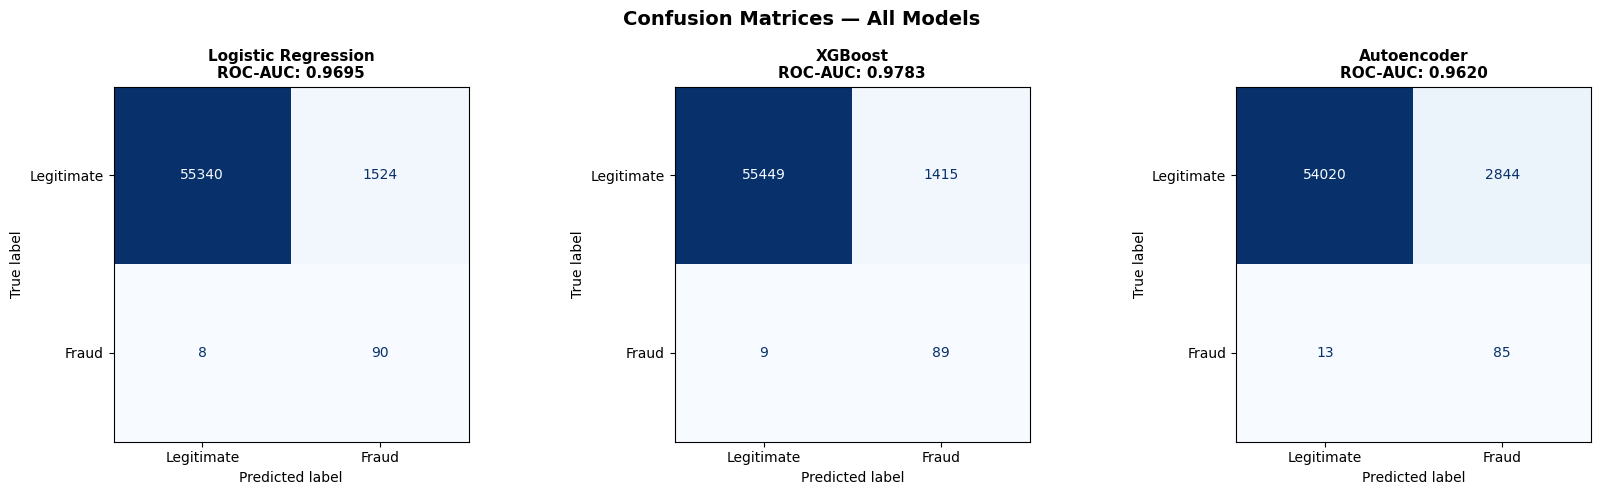

In [19]:
# ── Confusion Matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, prob, pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nROC-AUC: {roc_auc_score(y_test, prob):.4f}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── Detailed Classification Reports ───────────────────────────────────────────
for name, prob, pred, _ in models_info:
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, pred,
                                  target_names=['Legitimate','Fraud']))
    print(f'  ROC-AUC: {roc_auc_score(y_test, prob):.4f}\n')

  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

  ROC-AUC: 0.9695

  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.91      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

  ROC-AUC: 0.9783

  Autoencoder
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     56864
       Fraud       0.03      0.87      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.52 

In [21]:
# ── Summary Comparison Table ───────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, prob, pred, _ in models_info:
    summary_rows.append({
        'Model'        : name,
        'ROC-AUC'      : round(roc_auc_score(y_test, prob), 4),
        'Precision'    : round(precision_score(y_test, pred), 4),
        'Recall'       : round(recall_score(y_test, pred), 4),
        'F1-Score'     : round(f1_score(y_test, pred), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== Model Performance Summary ===')
summary_df.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc')

=== Model Performance Summary ===


,ROC-AUC,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.969500,0.055800,0.918400,0.105100
XGBoost,0.978300,0.059200,0.908200,0.111100
Autoencoder,0.962000,0.029000,0.867300,0.056200


---
## ⚡ Step 5: Simulate Real-Time Fraud Detection

Now we simulate how the best model would work in a **production / real-time scenario**. We take a random batch from the test set, run it through the model, and flag suspicious transactions — just like a live payment system would do.

We use **XGBoost** (typically the best performer) and set a probability threshold to decide what gets flagged.

In [22]:
# ── Real-time simulation function ──────────────────────────────────────────────
FRAUD_THRESHOLD = 0.5  # flag if probability > 50%

def simulate_realtime_detection(X_batch, y_batch_true, model, batch_size=20,
                                 threshold=FRAUD_THRESHOLD):
    """
    Simulates processing a batch of transactions in real-time.
    Prints each transaction's status and a summary at the end.
    """
    fraud_probs = model.predict_proba(X_batch)[:, 1]
    predictions = (fraud_probs >= threshold).astype(int)

    results = []
    print(f'{'─'*72}')
    print(f'{'Txn':>4}  {'Amount (€)':>10}  {'Fraud Prob':>10}  {'Prediction':>12}  {'Actual':>10}')
    print(f'{'─'*72}')

    # Recover original unscaled amounts from scaled data
    # (Amount is at column index -2 in our feature matrix)
    for i in range(batch_size):
        prob  = fraud_probs[i]
        pred  = predictions[i]
        true  = y_batch_true[i]
        flag  = '🚨 FRAUD'      if pred == 1 else '✅ OK'
        actual= '⚠️  FRAUD'   if true == 1 else 'Legitimate'
        match = '✓' if pred == true else '✗ MISS'

        print(f'{i+1:>4}  {'N/A':>10}  {prob:>10.4f}  {flag:>15}  {actual:>12}  {match}')
        results.append({'pred': pred, 'true': true, 'prob': prob})

    print(f'{'─'*72}')
    res_df = pd.DataFrame(results)
    tp = int(((res_df.pred==1) & (res_df.true==1)).sum())
    fp = int(((res_df.pred==1) & (res_df.true==0)).sum())
    fn = int(((res_df.pred==0) & (res_df.true==1)).sum())
    tn = int(((res_df.pred==0) & (res_df.true==0)).sum())
    print(f'\n📊 Batch Summary ({batch_size} transactions):')
    print(f'   ✅ True Positives  (Fraud caught)      : {tp}')
    print(f'   ❌ False Negatives (Fraud missed)      : {fn}')
    print(f'   ⚠️  False Positives (False alarm)      : {fp}')
    print(f'   ✔️  True Negatives  (Legit approved)   : {tn}')
    return res_df

# ── Run simulation on a balanced batch (includes known fraud cases) ────────────
np.random.seed(99)
# Sample 10 fraud + 10 legitimate from test set
fraud_idx = np.where(y_test == 1)[0]
legit_idx = np.where(y_test == 0)[0]
sample_idx = np.concatenate([
    np.random.choice(fraud_idx, 10, replace=False),
    np.random.choice(legit_idx, 10, replace=False)
])
np.random.shuffle(sample_idx)

X_sim = X_test[sample_idx]
y_sim = y_test[sample_idx]

print('🔴 Real-Time Fraud Detection — Live Transaction Simulation\n')
results = simulate_realtime_detection(X_sim, y_sim, xgb_model, batch_size=20)

🔴 Real-Time Fraud Detection — Live Transaction Simulation

────────────────────────────────────────────────────────────────────────
 Txn  Amount (€)  Fraud Prob    Prediction      Actual
────────────────────────────────────────────────────────────────────────
   1         N/A      1.0000          🚨 FRAUD     ⚠️  FRAUD  ✓
   2         N/A      0.0003             ✅ OK    Legitimate  ✓
   3         N/A      0.0005             ✅ OK    Legitimate  ✓
   4         N/A      0.4772             ✅ OK    Legitimate  ✓
   5         N/A      0.0001             ✅ OK    Legitimate  ✓
   6         N/A      0.0000             ✅ OK    Legitimate  ✓
   7         N/A      0.7391          🚨 FRAUD     ⚠️  FRAUD  ✓
   8         N/A      1.0000          🚨 FRAUD     ⚠️  FRAUD  ✓
   9         N/A      1.0000          🚨 FRAUD     ⚠️  FRAUD  ✓
  10         N/A      0.0027             ✅ OK    Legitimate  ✓
  11         N/A      0.0001             ✅ OK    Legitimate  ✓
  12         N/A      0.0002             ✅ OK  

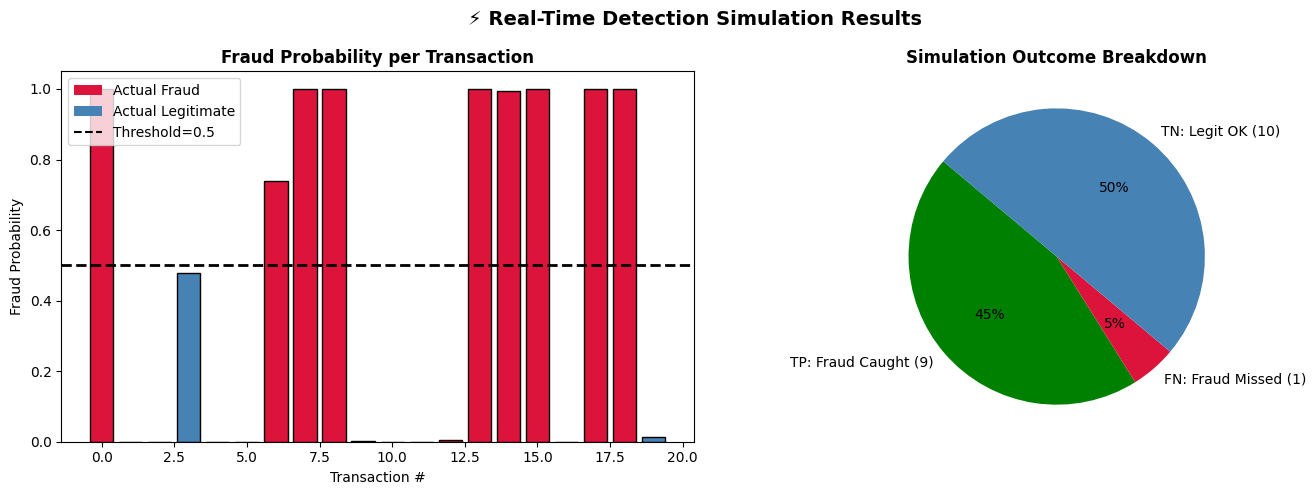

In [25]:
# ── Visualise real-time simulation results ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud probability bar chart
colors = ['crimson' if t == 1 else 'steelblue' for t in y_sim]
bars = axes[0].bar(range(20), results['prob'].values, color=colors, edgecolor='black')
axes[0].axhline(FRAUD_THRESHOLD, color='black', linestyle='--', lw=2,
                label=f'Threshold = {FRAUD_THRESHOLD}')
axes[0].set_title('Fraud Probability per Transaction', fontweight='bold')
axes[0].set_xlabel('Transaction #')
axes[0].set_ylabel('Fraud Probability')
axes[0].legend()

# Add legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='crimson', label='Actual Fraud'),
                   Patch(facecolor='steelblue', label='Actual Legitimate')]
axes[0].legend(handles=legend_elements + [plt.Line2D([0],[0],color='black',
               linestyle='--',label=f'Threshold={FRAUD_THRESHOLD}')])

# Outcome distribution pie
tp = int(((results.pred==1) & (results.true==1)).sum())
fp = int(((results.pred==1) & (results.true==0)).sum())
fn = int(((results.pred==0) & (results.true==1)).sum())
tn = int(((results.pred==0) & (results.true==0)).sum())

labels = [f'TP: Fraud Caught ({tp})', f'FN: Fraud Missed ({fn})',
          f'FP: False Alarm ({fp})', f'TN: Legit OK ({tn})']
sizes  = [tp, fn, fp, tn]
colors_pie = ['green', 'crimson', 'orange', 'steelblue']
axes[1].pie([s for s in sizes if s > 0],
            labels=[l for l, s in zip(labels, sizes) if s > 0],
            colors=[c for c, s in zip(colors_pie, sizes) if s > 0],
            autopct='%1.0f%%', startangle=140)
axes[1].set_title('Simulation Outcome Breakdown', fontweight='bold')

plt.suptitle('⚡ Real-Time Detection Simulation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏁 Conclusion

### Summary
We successfully built an end-to-end **Credit Card Fraud Detection system** that:

1. ✅ **Explored** 284,807 transactions with highly imbalanced classes (0.17% fraud)
2. ✅ **Addressed class imbalance** using SMOTE + undersampling
3. ✅ **Trained 3 models**: Logistic Regression, XGBoost, and Autoencoder
4. ✅ **Evaluated** using ROC-AUC and confusion matrices
5. ✅ **Simulated** real-time detection on live transactions